# Uncertainty Quantification Analysis

This notebook provides an interactive analysis of the uncertainty quantification improvements implemented in the ML model.

## Contents

1. Reproducibility Setup
2. Dependencies & Imports
3. Data Loading
4. Basic Model Evaluation (with progress tracking & caching)
5. Calibration Analysis (ECE, Brier Score, Reliability Diagram)
6. Per-Disease Calibration Breakdown
7. Multi-Metric Uncertainty Analysis
8. Uncertainty Separation Analysis
9. Threshold Optimization
10. Temperature Scaling Calibration
11. Summary and Recommendations

## 1. Reproducibility Setup

In [1]:
# Set random seeds for reproducibility
import random
import numpy as np
import torch

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

print(f"Random seed set to {SEED}")

Random seed set to 42


## 2. Dependencies & Imports

In [2]:
# Install required dependencies if missing
import subprocess
import sys

def install_packages():
    """Install all required packages for the notebook."""
    packages = [
        "datasets",        # HuggingFace dataset loading
        "scikit-learn",    # ROC/PR curves, metrics
        "matplotlib",      # Plotting
        "seaborn",         # Enhanced plotting
        "numpy",           # Numerical operations
        "scipy",           # Statistical functions and entropy
        "joblib",          # Caching
        "tqdm",            # Progress bars
        "flask",           # Backend import support
        "flask-cors",      # Backend import support
    ]
    
    for package in packages:
        subprocess.check_call([sys.executable, "-m", "pip", "install", "-q", package])
    
    print("✓ All dependencies installed successfully")

# Check if key packages are available, install if not
try:
    import datasets
    import joblib
    import tqdm
    import scipy  # noqa: F401
    import flask  # noqa: F401
    import flask_cors  # noqa: F401
    print("✓ All required packages are already installed")
except ImportError:
    print("Installing missing dependencies...")
    install_packages()

✓ All required packages are already installed


/home/notlath/Documents/Thesis/aill-be-sick/notebooks/.venv/lib/python3.14/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [3]:
import os
import sys
import json
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
import subprocess

# Disable eager Flask app bootstrap so backend service modules can be imported
# without triggering a circular import during notebook analysis.
os.environ.setdefault("APP_SKIP_AUTOCREATE", "1")

# Add backend to sys.path so 'import app' works
backend_path = str(Path.cwd().parent / "backend")
if backend_path not in sys.path:
    sys.path.insert(0, backend_path)

# Import uncertainty metrics
try:
    import flask  # noqa: F401
    import flask_cors  # noqa: F401
except ModuleNotFoundError:
    subprocess.check_call([sys.executable, "-m", "pip", "install", "-q", "flask", "flask-cors"])
    import flask  # noqa: F401
    import flask_cors  # noqa: F401

from app.services.ml_service import (
    eng_classifier,
    fil_classifier,
    compute_expected_calibration_error,
    compute_multi_metric_uncertainty,
    compute_reliability_diagram_data,
    compute_uncertainty_separation,
    optimize_uncertainty_threshold,
    apply_temperature_scaling,
    find_optimal_temperature,
)

# Plotting configuration
%matplotlib inline
sns.set_style("whitegrid")
plt.rcParams["figure.figsize"] = (12, 6)
plt.rcParams["font.size"] = 12

print("✓ Libraries loaded successfully")

[ML] Initializing Classifiers...


Loading weights: 100%|██████████| 201/201 [00:00<00:00, 12167.40it/s]


[ML] Classifiers Initialized
✓ Libraries loaded successfully


## 3. Data Loading

In [4]:
from datasets import load_dataset

def load_test_dataset(dataset_name: str, split: str = "test"):
    """Load test dataset from HuggingFace."""
    dataset = load_dataset(dataset_name, split=split)
    
    symptoms_list = [item["text"] for item in dataset]
    true_labels = [item["label"] for item in dataset]
    
    return symptoms_list, true_labels

# Load the English test dataset from HuggingFace
symptoms_list, true_labels = load_test_dataset("notlath/eng_dataset", split="test")
print(f"Loaded {len(symptoms_list)} test samples")
print(f"Diseases: {set(true_labels)}")

Loaded 450 test samples
Diseases: {0, 1, 2, 3, 4, 5}


## 4. Basic Model Evaluation

In [5]:
import joblib
from tqdm import tqdm
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, brier_score_loss
from scipy import stats
import torch
import torch.nn.functional as F

# Bootstrap confidence intervals
def bootstrap_ci(data, n_boot=1000, alpha=0.05):
    """Compute bootstrap confidence interval for a mean."""
    boots = [np.mean(np.random.choice(data, len(data))) for _ in range(n_boot)]
    return np.percentile(boots, [alpha / 2 * 100, (1 - alpha / 2) * 100])

def _run_mc_inference(classifier, text, n_iterations=50):
    """Run MC dropout inference and return all_predictions, logits, and mean_probs."""
    inputs = classifier.tokenizer(
        text,
        return_tensors="pt",
        truncation=True,
        padding=True,
    ).to(classifier.device)

    # Replicate inputs for batched MC inference
    input_ids = inputs["input_ids"].repeat(n_iterations, 1)
    attention_mask = inputs["attention_mask"].repeat(n_iterations, 1)

    # Activate dropout layers
    classifier.model.eval()
    for module in classifier.model.modules():
        if module.__class__.__name__.startswith("Dropout"):
            module.p = classifier.inference_dropout_rate
            module.train()
        elif "Norm" in module.__class__.__name__:
            module.eval()

    with torch.no_grad():
        outputs = classifier.model(input_ids=input_ids, attention_mask=attention_mask)
        logits = outputs.logits.cpu().numpy()  # [n_iterations, n_classes]
        probabilities = torch.softmax(outputs.logits, dim=-1).cpu().numpy()

    return logits, probabilities

def evaluate_classifier(classifier, symptoms_list, true_labels, model_name="Model", cache_path=None):
    """Run predictions and collect all metrics with progress tracking and error handling."""
    
    # Load from cache if available
    if cache_path and Path(cache_path).exists():
        print(f"Loading cached results from {cache_path}")
        return joblib.load(cache_path)
    
    predicted_classes = []
    predicted_labels = []
    confidences = []
    mean_probs = []
    std_probs = []
    predictive_entropies = []
    mutual_informations = []
    mc_predictions = []  # Raw [n_iterations, n_classes] arrays
    logits_list = []     # Raw logits [n_iterations, n_classes]
    failed_indices = []
    n_iterations = classifier.n_iterations
    
    # Progress bar for evaluation
    for i, symptoms in enumerate(tqdm(symptoms_list, desc=f"Evaluating {model_name}")):
        try:
            # Run MC inference directly to get all_predictions and logits
            logits, all_preds = _run_mc_inference(
                classifier, symptoms, n_iterations=n_iterations
            )
            
            # Compute statistics
            mean_p = all_preds.mean(axis=0)  # [n_classes]
            std_p = all_preds.std(axis=0)    # [n_classes]
            pred_class = mean_p.argmax(axis=-1)
            conf = mean_p.max(axis=-1)
            pred_entropy = float(stats.entropy(mean_p, axis=-1))
            
            # Mutual information: H(E[p]) - E[H(p)]
            expected_entropy = np.mean([stats.entropy(p, axis=-1) for p in all_preds], axis=0)
            entropy_of_expected = stats.entropy(mean_p, axis=-1)
            mi = float(entropy_of_expected - expected_entropy)
            
            predicted_classes.append(int(pred_class))
            predicted_labels.append(str(classifier.model.config.id2label[int(pred_class)]))
            confidences.append(float(conf))
            mean_probs.append(mean_p)
            std_probs.append(std_p)
            predictive_entropies.append(pred_entropy)
            mutual_informations.append(mi)
            mc_predictions.append(all_preds)       # [n_iterations, n_classes]
            logits_list.append(logits)              # [n_iterations, n_classes]
        except Exception as e:
            print(f"\n⚠️  Failed on sample {i}: {e}")
            failed_indices.append(i)
            # Use placeholder values to keep alignment
            predicted_classes.append(-1)
            predicted_labels.append(None)
            confidences.append(0.0)
            mean_probs.append(np.zeros(classifier.model.config.num_labels))
            std_probs.append(np.zeros(classifier.model.config.num_labels))
            predictive_entropies.append(0.0)
            mutual_informations.append(0.0)
            mc_predictions.append(np.zeros((n_iterations, classifier.model.config.num_labels)))
            logits_list.append(np.zeros((n_iterations, classifier.model.config.num_labels)))
    
    if failed_indices:
        print(f"\n⚠️  {len(failed_indices)} samples failed. Excluding from metrics.")
    
    # Convert to numpy
    predicted_classes = np.array(predicted_classes)
    confidences = np.array(confidences)
    mean_probs = np.array(mean_probs)
    std_probs = np.array(std_probs)
    predictive_entropies = np.array(predictive_entropies)
    mutual_informations = np.array(mutual_informations)
    mc_predictions = np.array(mc_predictions)  # [n_samples, n_iterations, n_classes]
    logits_list = np.array(logits_list)         # [n_samples, n_iterations, n_classes]
    
    # Convert labels to indices (handle both string names and integer labels)
    label_to_idx = classifier.model.config.label2id
    
    # Check if labels are already integers or need string-to-index mapping
    if len(true_labels) > 0 and isinstance(true_labels[0], (int, np.integer)):
        true_labels_idx = np.array(true_labels)
    else:
        true_labels_idx = np.array([label_to_idx[label] for label in true_labels])
    
    # Filter out failed samples
    valid_mask = predicted_classes >= 0
    true_labels_idx = true_labels_idx[valid_mask]
    predicted_classes = predicted_classes[valid_mask]
    confidences = confidences[valid_mask]
    mean_probs = mean_probs[valid_mask]
    std_probs = std_probs[valid_mask]
    predictive_entropies = predictive_entropies[valid_mask]
    mutual_informations = mutual_informations[valid_mask]
    mc_predictions = mc_predictions[valid_mask]
    logits_list = logits_list[valid_mask]
    predicted_labels = [label for label in predicted_labels if label is not None]
    
    # Compute accuracy
    accuracies = (predicted_classes == true_labels_idx).astype(int)
    accuracy = accuracy_score(true_labels_idx, predicted_classes)
    acc_ci = bootstrap_ci(accuracies)
    
    # Compute Brier score (multi-class, one-vs-rest)
    n_classes = classifier.model.config.num_labels
    brier_scores = []
    for c in range(n_classes):
        binary_true = (true_labels_idx == c).astype(int)
        brier_scores.append(brier_score_loss(binary_true, mean_probs[:, c]))
    brier_mean = np.mean(brier_scores)
    
    print(f"\n{'='*60}")
    print(f"{model_name}")
    print(f"{'='*60}")
    print(f"Samples evaluated: {len(accuracies)} / {len(symptoms_list)}")
    print(f"Accuracy: {accuracy:.4f} ({accuracy*100:.2f}%) [95% CI: {acc_ci[0]:.4f} - {acc_ci[1]:.4f}]")
    print(f"Average Confidence: {np.mean(confidences):.4f}")
    print(f"Calibration Gap: {np.mean(confidences) - accuracy:.4f}")
    print(f"Brier Score (mean): {brier_mean:.4f}")
    print(f"Mean MI: {np.mean(mutual_informations):.4f} ± {np.std(mutual_informations):.4f}")
    
    # Classification report
    class_names = [classifier.model.config.id2label[idx] for idx in sorted(classifier.model.config.id2label)]
    print(f"\nClassification Report:")
    print(
        classification_report(
            true_labels_idx,
            predicted_classes,
            labels=list(range(n_classes)),
            target_names=class_names,
            zero_division=0,
        )
    )
    
    results = {
        "predictions": predicted_labels,
        "predicted_classes": predicted_classes,
        "confidences": confidences,
        "mean_probs": mean_probs,
        "std_probs": std_probs,
        "predictive_entropy": predictive_entropies,
        "mutual_information": mutual_informations,
        "mc_predictions": mc_predictions,    # [n_samples, n_iterations, n_classes]
        "logits": logits_list,                # [n_samples, n_iterations, n_classes]
        "true_labels_idx": true_labels_idx,
        "pred_labels_idx": predicted_classes,
        "accuracies": accuracies,
        "accuracy": accuracy,
        "accuracy_ci": acc_ci,
        "brier_scores": brier_scores,
        "brier_mean": brier_mean,
        "failed_indices": failed_indices,
        "class_names": class_names,
    }
    
    # Save to cache
    if cache_path:
        Path(cache_path).parent.mkdir(parents=True, exist_ok=True)
        joblib.dump(results, cache_path)
        print(f"Results cached to {cache_path}")
    
    return results

In [6]:
# Evaluate English model (with caching)
cache_dir = Path("cache")
cache_dir.mkdir(exist_ok=True)

eng_results = evaluate_classifier(
    eng_classifier, symptoms_list, true_labels,
    "BioClinical ModernBERT (English)",
    cache_path=str(cache_dir / "eng_results.pkl")
)

Loading cached results from cache/eng_results.pkl


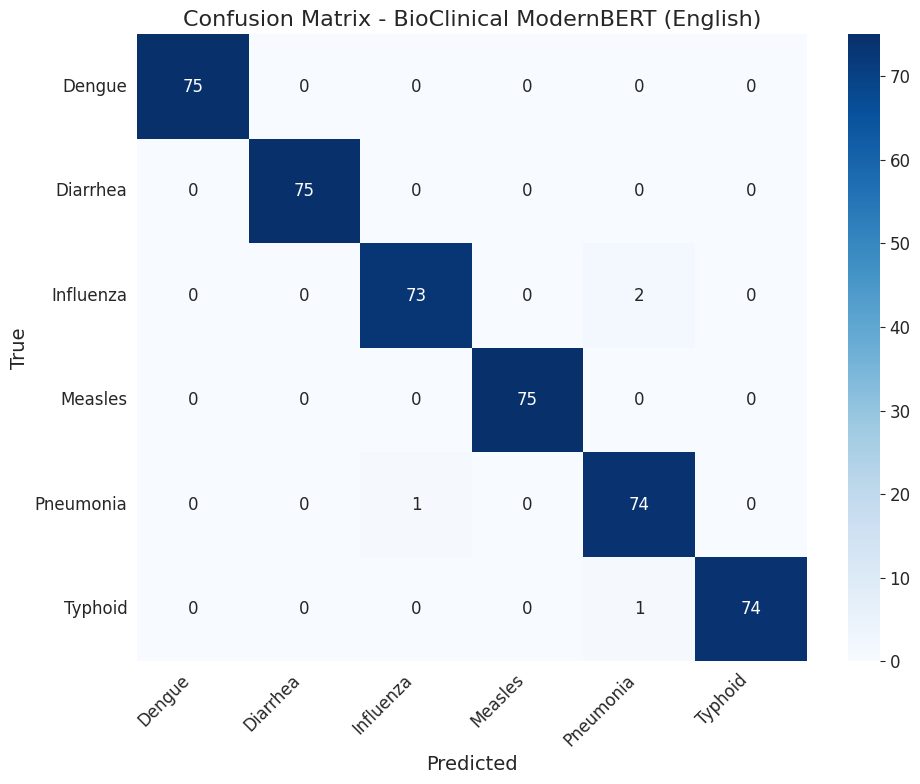

In [7]:
# Confusion Matrix Visualization
cm = confusion_matrix(
    eng_results["true_labels_idx"],
    eng_results["pred_labels_idx"],
    labels=list(range(len(eng_results["class_names"]))),
)

fig, ax = plt.subplots(figsize=(10, 8))
sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues',
    ax=ax,
    xticklabels=eng_results["class_names"],
    yticklabels=eng_results["class_names"],
)
ax.set_xlabel('Predicted', fontsize=14)
ax.set_ylabel('True', fontsize=14)
ax.set_title('Confusion Matrix - BioClinical ModernBERT (English)', fontsize=16)
plt.xticks(rotation=45, ha='right')
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()

## 5. Calibration Analysis

In [8]:
# Compute Expected Calibration Error
ece = compute_expected_calibration_error(
    eng_results["pred_labels_idx"],
    eng_results["confidences"],
    eng_results["true_labels_idx"],
    n_bins=10
)

print(f"Expected Calibration Error (ECE): {ece:.4f}")
print(f"Interpretation: {'Well calibrated' if ece < 0.05 else 'Needs calibration'}")
print(f"Brier Score (mean): {eng_results['brier_mean']:.4f}")

Expected Calibration Error (ECE): 0.0814
Interpretation: Needs calibration
Brier Score (mean): 0.0038


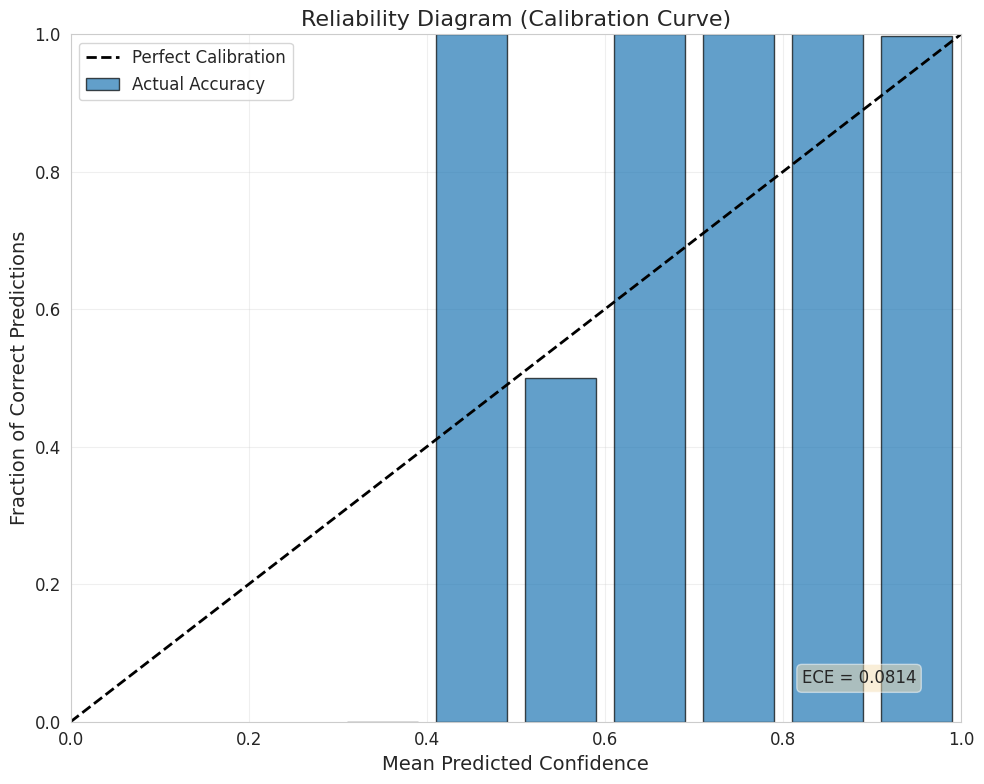

In [9]:
# Plot Reliability Diagram
rel_data = compute_reliability_diagram_data(
    eng_results["confidences"],
    eng_results["accuracies"],
    n_bins=10
)

fig, ax = plt.subplots(figsize=(10, 8))

# Perfect calibration line
ax.plot([0, 1], [0, 1], 'k--', label='Perfect Calibration', linewidth=2)

# Actual calibration
ax.bar(rel_data["bin_centers"], rel_data["accuracies"], width=0.08, 
       alpha=0.7, label='Actual Accuracy', edgecolor='black')

ax.set_xlabel('Mean Predicted Confidence', fontsize=14)
ax.set_ylabel('Fraction of Correct Predictions', fontsize=14)
ax.set_title('Reliability Diagram (Calibration Curve)', fontsize=16)
ax.legend(loc='upper left')
ax.set_xlim([0, 1])
ax.set_ylim([0, 1])
ax.grid(True, alpha=0.3)

# Add ECE annotation
ax.text(0.95, 0.05, f'ECE = {ece:.4f}', transform=ax.transAxes, 
        fontsize=12, verticalalignment='bottom', horizontalalignment='right',
        bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.5))

plt.tight_layout()
plt.show()

## 6. Per-Disease Calibration Breakdown

PER-DISEASE BREAKDOWN
Dengue               | n=  75 | Acc=1.000 | Conf=0.925 | ECE=0.0752
Diarrhea             | n=  75 | Acc=1.000 | Conf=0.921 | ECE=0.0792
Influenza            | n=  75 | Acc=0.973 | Conf=0.898 | ECE=0.0862
Measles              | n=  75 | Acc=1.000 | Conf=0.929 | ECE=0.0712
Pneumonia            | n=  75 | Acc=0.987 | Conf=0.894 | ECE=0.0930
Typhoid              | n=  75 | Acc=0.987 | Conf=0.907 | ECE=0.0819


/tmp/ipykernel_49643/3234523792.py:55: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  axes[1].set_xticklabels(diseases, rotation=45, ha='right')


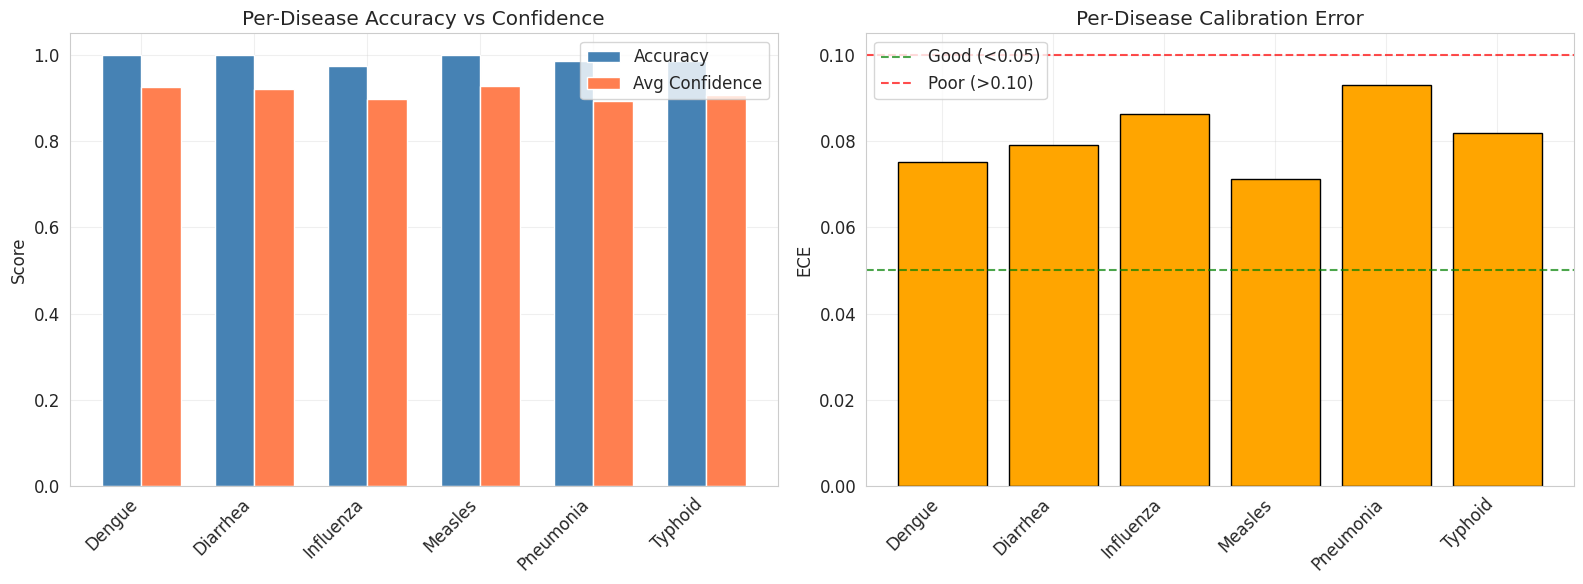

In [10]:
# Per-disease accuracy and calibration
print("="*60)
print("PER-DISEASE BREAKDOWN")
print("="*60)

class_names = eng_results["class_names"]
true_idx = eng_results["true_labels_idx"]
pred_idx = eng_results["pred_labels_idx"]
confs = eng_results["confidences"]
accs = eng_results["accuracies"]

disease_stats = []
for c in range(len(class_names)):
    mask = true_idx == c
    n_samples = mask.sum()
    if n_samples == 0:
        continue
    disease_acc = accs[mask].mean()
    disease_conf = confs[mask].mean()
    disease_ece = compute_expected_calibration_error(pred_idx[mask], confs[mask], true_idx[mask], n_bins=5)
    disease_stats.append({
        "disease": class_names[c],
        "n_samples": n_samples,
        "accuracy": disease_acc,
        "avg_confidence": disease_conf,
        "ece": disease_ece,
    })
    print(f"{class_names[c]:20s} | n={n_samples:4d} | Acc={disease_acc:.3f} | Conf={disease_conf:.3f} | ECE={disease_ece:.4f}")

# Plot per-disease calibration
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

diseases = [s["disease"] for s in disease_stats]
accuracies = [s["accuracy"] for s in disease_stats]
confidences = [s["avg_confidence"] for s in disease_stats]
eces = [s["ece"] for s in disease_stats]

# Accuracy vs Confidence
x = np.arange(len(diseases))
width = 0.35
axes[0].bar(x - width/2, accuracies, width, label='Accuracy', color='steelblue')
axes[0].bar(x + width/2, confidences, width, label='Avg Confidence', color='coral')
axes[0].set_xticks(x)
axes[0].set_xticklabels(diseases, rotation=45, ha='right')
axes[0].set_ylabel('Score')
axes[0].set_title('Per-Disease Accuracy vs Confidence')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# ECE per disease
colors = ['green' if e < 0.05 else 'orange' if e < 0.10 else 'red' for e in eces]
axes[1].bar(diseases, eces, color=colors, edgecolor='black')
axes[1].axhline(y=0.05, color='green', linestyle='--', alpha=0.7, label='Good (<0.05)')
axes[1].axhline(y=0.10, color='red', linestyle='--', alpha=0.7, label='Poor (>0.10)')
axes[1].set_xticklabels(diseases, rotation=45, ha='right')
axes[1].set_ylabel('ECE')
axes[1].set_title('Per-Disease Calibration Error')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

## 7. Multi-Metric Uncertainty Analysis

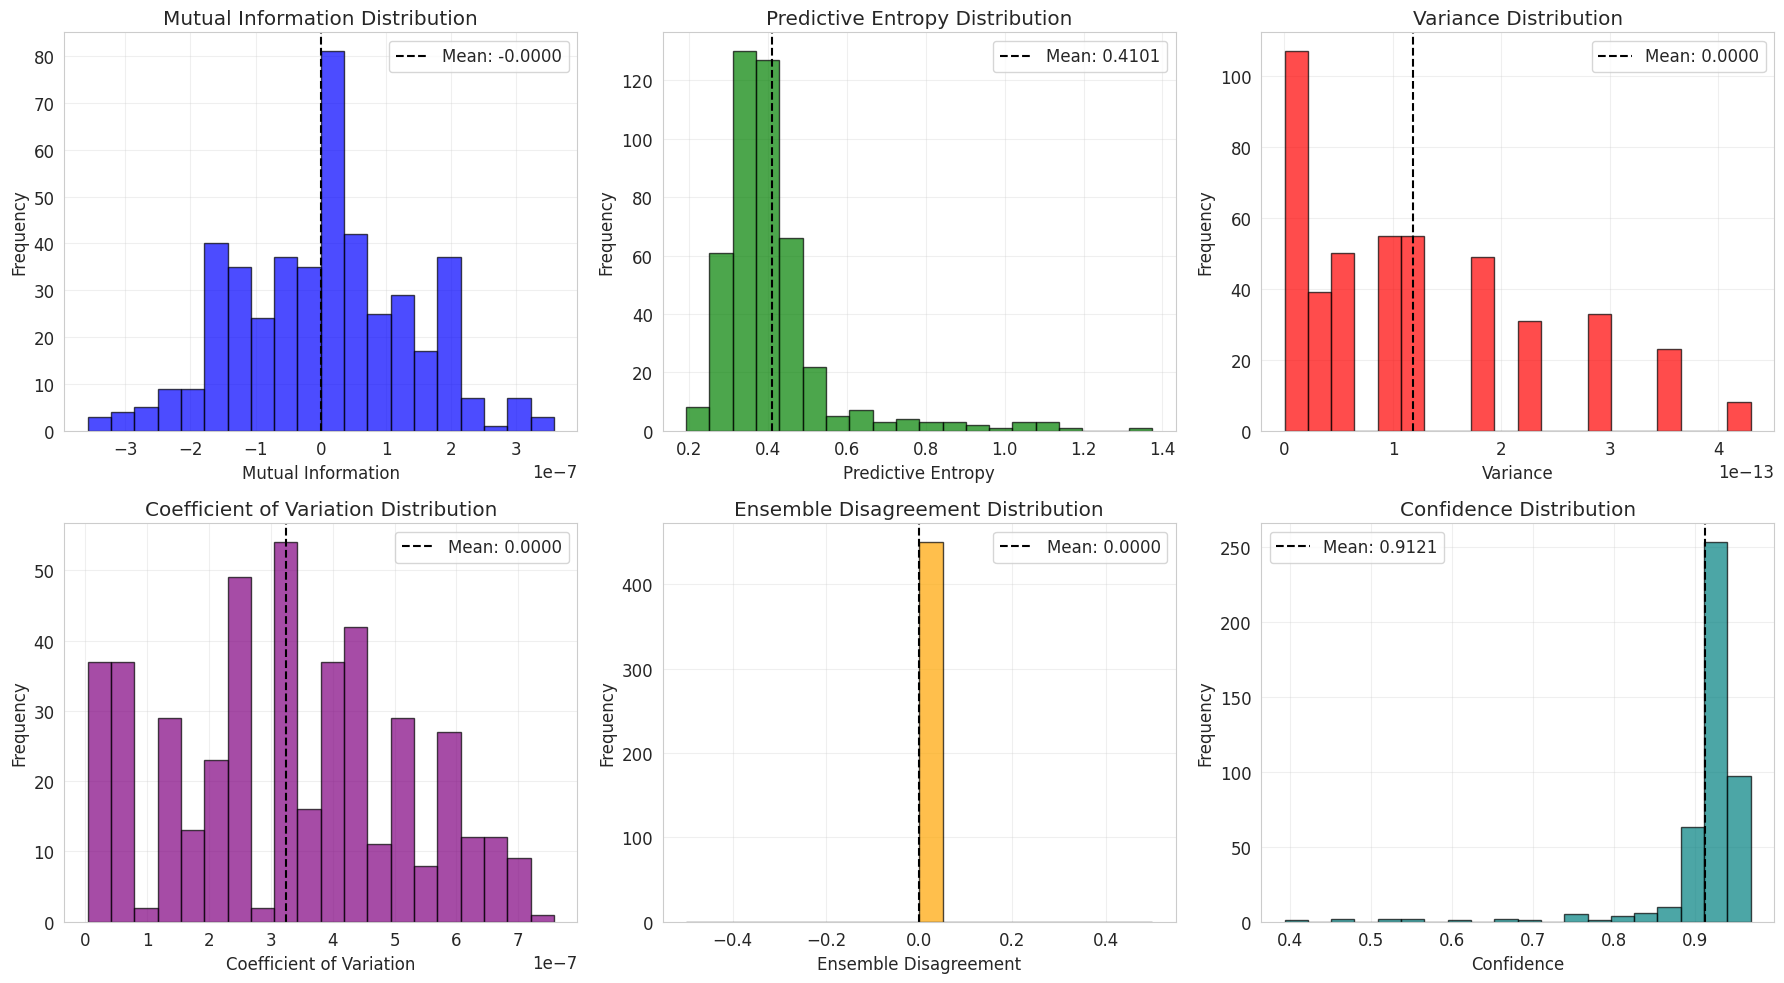


Uncertainty Metric Statistics:
  Mutual Information:      -0.0000 ± 0.0000
  Predictive Entropy:      0.4101 ± 0.1460
  Variance:                0.0000 ± 0.0000
  Coefficient of Variation: 0.0000 ± 0.0000
  Ensemble Disagreement:   0.0000 ± 0.0000


In [11]:
# Use cached mc_predictions to compute true multi-metric uncertainty values.
# mc_predictions shape: [n_samples, n_iterations, n_classes]
mc_preds = eng_results["mc_predictions"]  # [n_samples, n_iterations, n_classes]
mean_probs_arr = np.asarray(eng_results["mean_probs"], dtype=float)
std_probs_arr = np.asarray(eng_results["std_probs"], dtype=float)

# Compute per-sample multi-metric uncertainty using actual MC samples
mi_values = np.array([
    compute_multi_metric_uncertainty(mc_preds[i], mean_probs_arr[i], std_probs_arr[i])["mutual_information"]
    for i in range(len(mc_preds))
], dtype=float)

entropy_values = np.array([
    compute_multi_metric_uncertainty(mc_preds[i], mean_probs_arr[i], std_probs_arr[i])["predictive_entropy"]
    for i in range(len(mc_preds))
], dtype=float)

variance_values = np.array([
    compute_multi_metric_uncertainty(mc_preds[i], mean_probs_arr[i], std_probs_arr[i])["variance"]
    for i in range(len(mc_preds))
], dtype=float)

cv_values = np.array([
    compute_multi_metric_uncertainty(mc_preds[i], mean_probs_arr[i], std_probs_arr[i])["coefficient_of_variation"]
    for i in range(len(mc_preds))
], dtype=float)

disagreement_values = np.array([
    compute_multi_metric_uncertainty(mc_preds[i], mean_probs_arr[i], std_probs_arr[i])["ensemble_disagreement"]
    for i in range(len(mc_preds))
], dtype=float)

# Plot uncertainty metric distributions
fig, axes = plt.subplots(2, 3, figsize=(18, 10))
axes = axes.flatten()

metrics = [
    (mi_values, "Mutual Information", "blue"),
    (entropy_values, "Predictive Entropy", "green"),
    (variance_values, "Variance", "red"),
    (cv_values, "Coefficient of Variation", "purple"),
    (disagreement_values, "Ensemble Disagreement", "orange"),
    (eng_results["confidences"], "Confidence", "teal"),
]

for idx, (values, name, color) in enumerate(metrics):
    values = np.asarray(values, dtype=float)
    axes[idx].hist(values, bins=20, color=color, alpha=0.7, edgecolor='black')
    axes[idx].axvline(np.mean(values), color='black', linestyle='--', 
                     label=f'Mean: {np.mean(values):.4f}')
    axes[idx].set_xlabel(name)
    axes[idx].set_ylabel('Frequency')
    axes[idx].set_title(f'{name} Distribution')
    axes[idx].legend()
    axes[idx].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# Print statistics
print("\nUncertainty Metric Statistics:")
print(f"  Mutual Information:      {mi_values.mean():.4f} ± {mi_values.std():.4f}")
print(f"  Predictive Entropy:      {entropy_values.mean():.4f} ± {entropy_values.std():.4f}")
print(f"  Variance:                {variance_values.mean():.4f} ± {variance_values.std():.4f}")
print(f"  Coefficient of Variation: {cv_values.mean():.4f} ± {cv_values.std():.4f}")
print(f"  Ensemble Disagreement:   {disagreement_values.mean():.4f} ± {disagreement_values.std():.4f}")

## 8. Uncertainty Separation Analysis

UNCERTAINTY SEPARATION ANALYSIS

Mutual Information:
  Mean (Correct):   0.0000
  Mean (Incorrect): -0.0000
  Separation:       -0.0000
  AUC-ROC:          0.3089

Variance Proxy:
  Mean (Correct):   0.0000
  Mean (Incorrect): 0.0000
  Separation:       -0.0000
  AUC-ROC:          0.3153

Coefficient of Variation:
  Mean (Correct):   0.0000
  Mean (Incorrect): 0.0000
  Separation:       0.0000
  AUC-ROC:          0.5348

Disagreement Proxy:
  Mean (Correct):   0.0000
  Mean (Incorrect): 0.0000
  Separation:       0.0000
  AUC-ROC:          0.5000


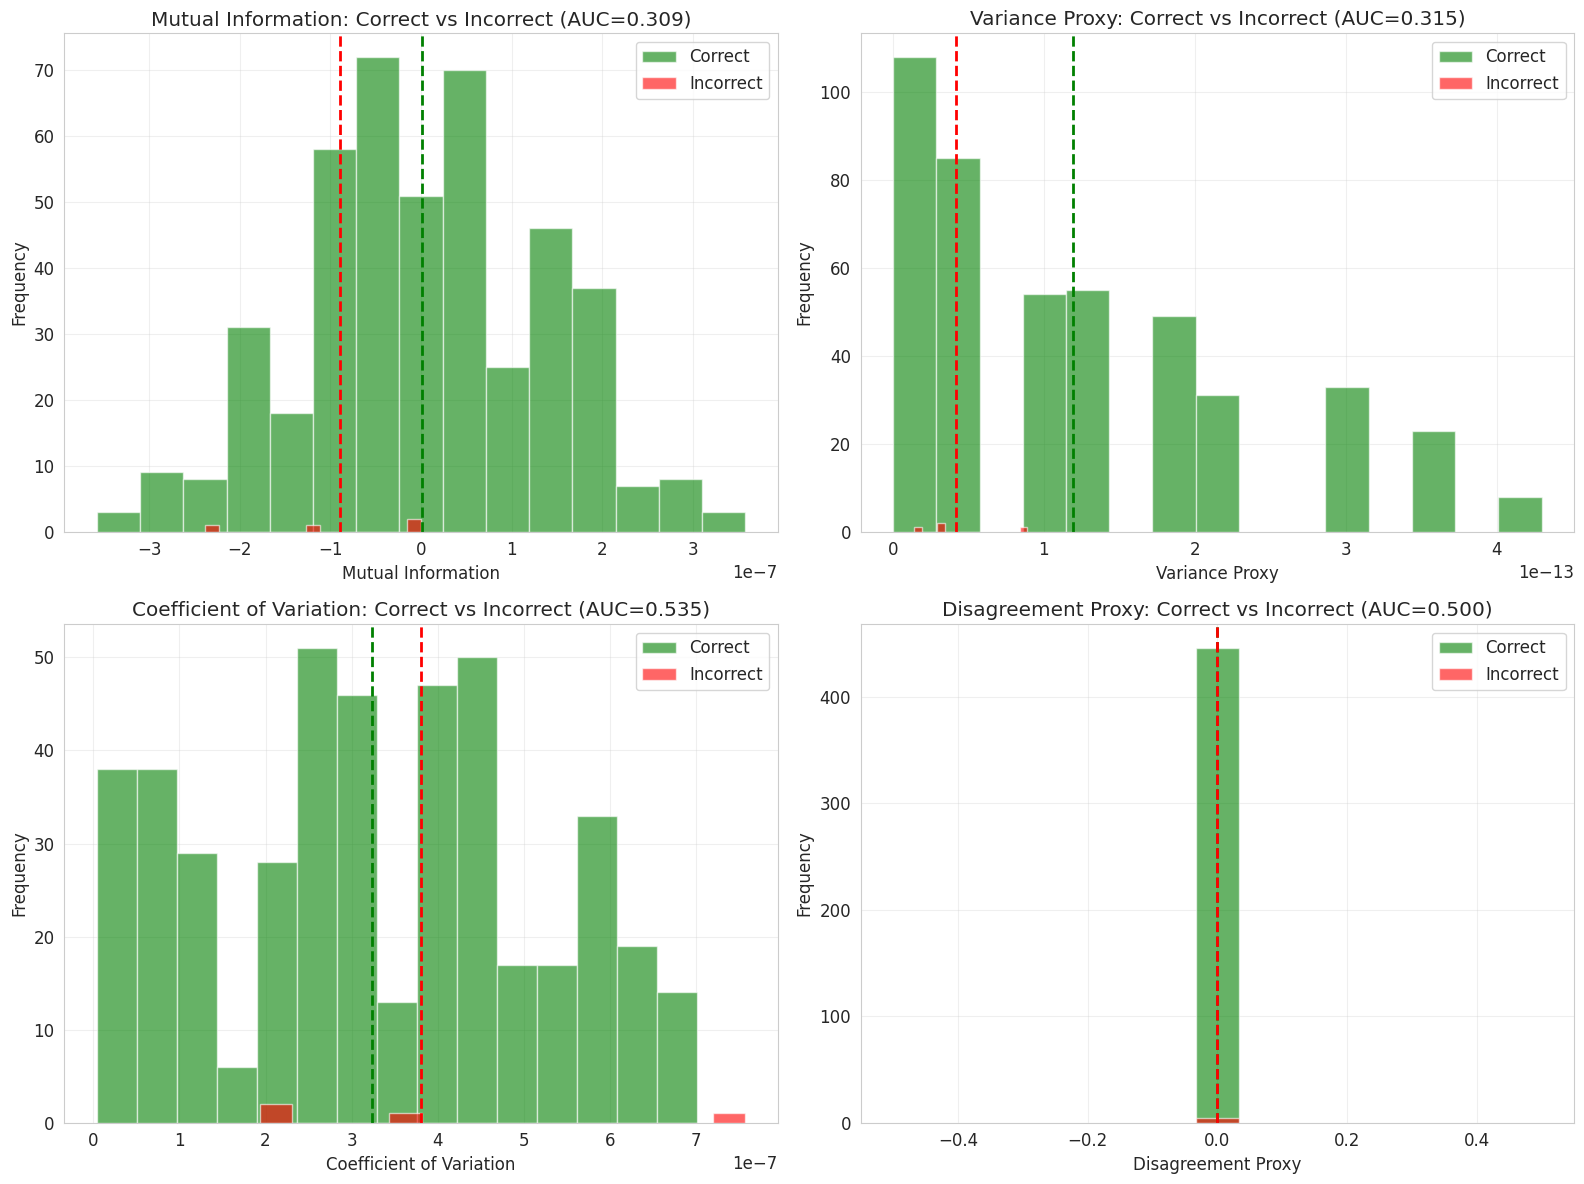

In [12]:
# Analyze how well each metric separates correct from incorrect predictions
print("="*60)
print("UNCERTAINTY SEPARATION ANALYSIS")
print("="*60)

metrics_to_analyze = [
    (mi_values, "Mutual Information"),
    (variance_values, "Variance Proxy"),
    (cv_values, "Coefficient of Variation"),
    (disagreement_values, "Disagreement Proxy"),
]

fig, axes = plt.subplots(2, 2, figsize=(16, 12))
axes = axes.flatten()

for idx, (values, name) in enumerate(metrics_to_analyze):
    separation = compute_uncertainty_separation(values, eng_results["accuracies"])
    
    if separation["can_evaluate"]:
        print(f"\n{name}:")
        print(f"  Mean (Correct):   {separation['mean_uncertainty_correct']:.4f}")
        print(f"  Mean (Incorrect): {separation['mean_uncertainty_incorrect']:.4f}")
        print(f"  Separation:       {separation['separation_mean']:.4f}")
        print(f"  AUC-ROC:          {separation['auc']:.4f}")
        
        # Plot distribution
        correct_vals = values[eng_results["accuracies"] == 1]
        incorrect_vals = values[eng_results["accuracies"] == 0]
        
        axes[idx].hist(correct_vals, bins=15, alpha=0.6, label='Correct', color='green')
        axes[idx].hist(incorrect_vals, bins=15, alpha=0.6, label='Incorrect', color='red')
        axes[idx].axvline(separation['mean_uncertainty_correct'], color='green', 
                         linestyle='--', linewidth=2)
        axes[idx].axvline(separation['mean_uncertainty_incorrect'], color='red', 
                         linestyle='--', linewidth=2)
        axes[idx].set_xlabel(name)
        axes[idx].set_ylabel('Frequency')
        axes[idx].set_title(f'{name}: Correct vs Incorrect (AUC={separation["auc"]:.3f})')
        axes[idx].legend()
        axes[idx].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

## 9. Threshold Optimization

THRESHOLD OPTIMIZATION
Mutual Information Optimal Threshold:
  F1-optimal:     -0.0000
  ROC-optimal:    -0.0000
  PR-optimal:     -0.0000


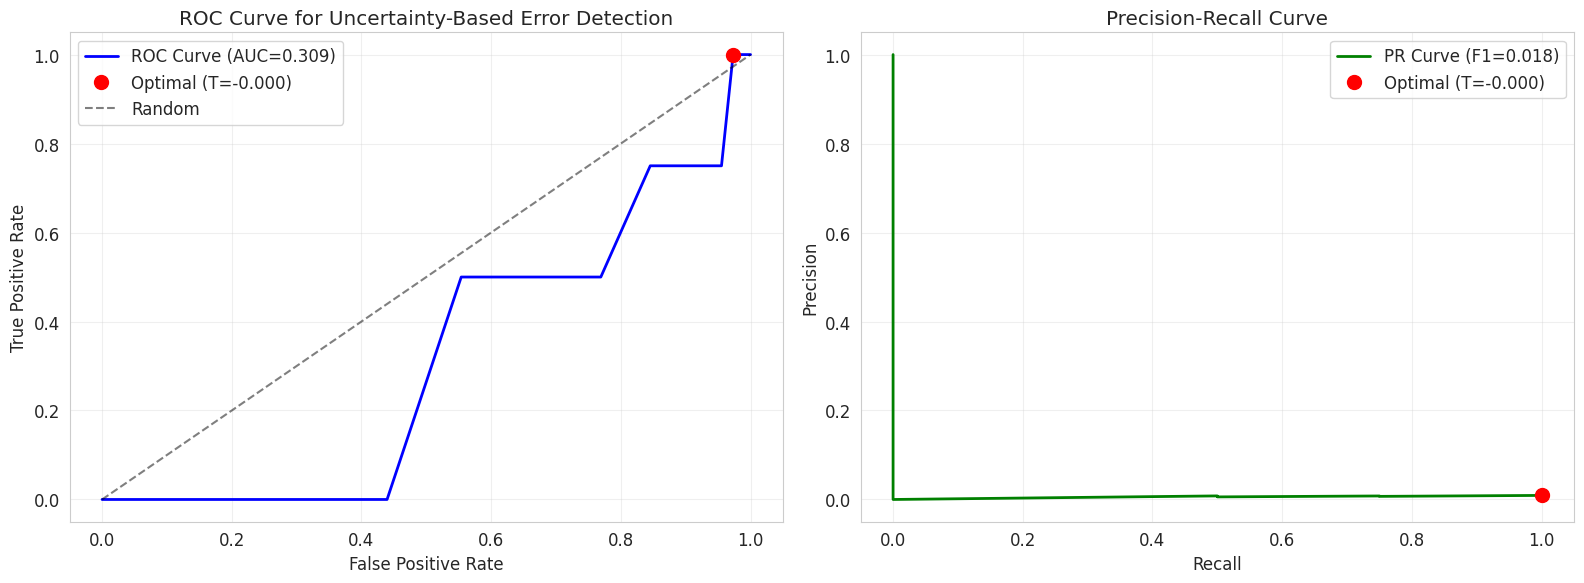

In [13]:
from sklearn.metrics import roc_curve, precision_recall_curve

print("="*60)
print("THRESHOLD OPTIMIZATION")
print("="*60)

# Optimize MI threshold
mi_optimal = optimize_uncertainty_threshold(mi_values, eng_results["accuracies"], metric="f1")

print(f"Mutual Information Optimal Threshold:")
f1_thresh = mi_optimal.get("threshold")
roc_thresh = mi_optimal.get("roc_optimal_threshold")
pr_thresh = mi_optimal.get("pr_optimal_threshold")
print(f"  F1-optimal:     {f1_thresh:.4f}" if f1_thresh is not None else "  F1-optimal:     N/A (all predictions correct)")
print(f"  ROC-optimal:    {roc_thresh:.4f}" if roc_thresh is not None else "  ROC-optimal:    N/A")
print(f"  PR-optimal:     {pr_thresh:.4f}" if pr_thresh is not None else "  PR-optimal:     N/A")

# Plot ROC curve
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# ROC Curve
fpr, tpr, thresholds = roc_curve(eng_results["accuracies"] == 0, mi_values)
youden_index = tpr - fpr
optimal_idx = np.argmax(youden_index)

axes[0].plot(fpr, tpr, "b-", linewidth=2, label=f"ROC Curve (AUC={np.trapz(tpr, fpr):.3f})")
axes[0].plot(fpr[optimal_idx], tpr[optimal_idx], "ro", markersize=10, 
            label=f"Optimal (T={thresholds[optimal_idx]:.3f})")
axes[0].plot([0, 1], [0, 1], "k--", alpha=0.5, label="Random")
axes[0].set_xlabel("False Positive Rate")
axes[0].set_ylabel("True Positive Rate")
axes[0].set_title("ROC Curve for Uncertainty-Based Error Detection")
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# Precision-Recall Curve
precision, recall, pr_thresholds = precision_recall_curve(eng_results["accuracies"] == 0, mi_values)
pr_scores = 2 * precision * recall / (precision + recall + 1e-10)
optimal_pr_idx = np.argmax(pr_scores)

axes[1].plot(recall, precision, "g-", linewidth=2, 
            label=f"PR Curve (F1={pr_scores[optimal_pr_idx]:.3f})")
axes[1].plot(recall[optimal_pr_idx], precision[optimal_pr_idx], "ro", markersize=10,
            label=f"Optimal (T={pr_thresholds[optimal_pr_idx]:.3f})")
axes[1].set_xlabel("Recall")
axes[1].set_ylabel("Precision")
axes[1].set_title("Precision-Recall Curve")
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()


## 10. Temperature Scaling Calibration

Temperature Scaling Analysis
Optimal Temperature: 0.500
Interpretation:
  Model is underconfident. Apply T=0.50 to sharpen predictions.


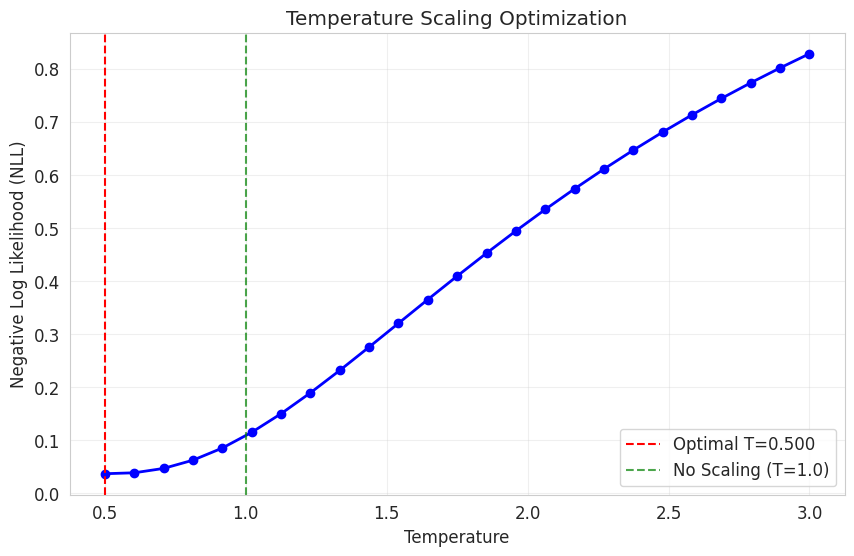

In [14]:
# Temperature scaling using actual logits from MC inference.
# logits shape: [n_samples, n_iterations, n_classes]
# We use the mean logits across MC iterations as the representative logits per sample.

print("Temperature Scaling Analysis")
print("="*60)

# Mean logits across MC iterations: [n_samples, n_classes]
mean_logits = np.asarray(eng_results["logits"], dtype=float).mean(axis=1)

# Find optimal temperature using actual logits
optimal_temp = find_optimal_temperature(
    mean_logits, eng_results["true_labels_idx"],
    temperature_range=(0.5, 3.0), n_steps=25
)

print(f"Optimal Temperature: {optimal_temp:.3f}")
print(f"Interpretation:")
if optimal_temp > 1.1:
    print(f"  Model is overconfident. Apply T={optimal_temp:.2f} to soften predictions.")
elif optimal_temp < 0.9:
    print(f"  Model is underconfident. Apply T={optimal_temp:.2f} to sharpen predictions.")
else:
    print(f"  Model is well-calibrated. No temperature scaling needed.")

# Plot temperature vs NLL
temperatures = np.linspace(0.5, 3.0, 25)
nll_values = []

for temp in temperatures:
    scaled_probs = apply_temperature_scaling(mean_logits, temp)
    nll = -np.mean(np.log(scaled_probs[np.arange(len(eng_results["true_labels_idx"])),
                                       eng_results["true_labels_idx"]] + 1e-10))
    nll_values.append(nll)

plt.figure(figsize=(10, 6))
plt.plot(temperatures, nll_values, 'b-o', linewidth=2, markersize=6)
plt.axvline(optimal_temp, color='red', linestyle='--',
           label=f'Optimal T={optimal_temp:.3f}')
plt.axvline(1.0, color='green', linestyle='--', alpha=0.7, label='No Scaling (T=1.0)')
plt.xlabel('Temperature')
plt.ylabel('Negative Log Likelihood (NLL)')
plt.title('Temperature Scaling Optimization')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

## 11. Summary and Recommendations

In [15]:
print("="*60)
print("SUMMARY AND RECOMMENDATIONS")
print("="*60)

recommendations = []

# Calibration assessment
calibration_gap = np.mean(eng_results["confidences"]) - eng_results["accuracy"]
if abs(calibration_gap) > 0.05:
    if calibration_gap > 0:
        recommendations.append(f"⚠️  Model is OVERCONFIDENT (gap={calibration_gap:.3f})")
        recommendations.append(f"   → Apply temperature scaling with T ≈ {optimal_temp:.2f}")
    else:
        recommendations.append(f"⚠️  Model is UNDERCONFIDENT (gap={calibration_gap:.3f})")
        recommendations.append(f"   → Apply temperature scaling with T ≈ {optimal_temp:.2f}")
else:
    recommendations.append("✓ Model is well-calibrated")

# ECE assessment
if ece < 0.05:
    recommendations.append(f"✓ ECE is acceptable ({ece:.4f})")
else:
    recommendations.append(f"⚠️  ECE needs improvement ({ece:.4f} > 0.05)")

# Brier score assessment
if eng_results["brier_mean"] < 0.05:
    recommendations.append(f"✓ Brier score is good ({eng_results['brier_mean']:.4f})")
else:
    recommendations.append(f"⚠️  Brier score needs improvement ({eng_results['brier_mean']:.4f})")

# Uncertainty separation assessment for each metric
separation_metrics = [
    (mi_values, "MI"),
    (variance_values, "Variance"),
    (disagreement_values, "Disagreement"),
]
for values, name in separation_metrics:
    sep = compute_uncertainty_separation(values, eng_results["accuracies"])
    if sep["can_evaluate"]:
        if sep["auc"] > 0.7:
            recommendations.append(f"✓ {name} effectively separates correct/incorrect (AUC={sep['auc']:.3f})")
        elif sep["auc"] > 0.6:
            recommendations.append(f"⚠️  {name} has moderate separation (AUC={sep['auc']:.3f})")
        else:
            recommendations.append(f"⚠️  {name} has poor separation (AUC={sep['auc']:.3f})")

# Accuracy CI
recommendations.append(f"Accuracy: {eng_results['accuracy']:.4f} [95% CI: {eng_results['accuracy_ci'][0]:.4f} - {eng_results['accuracy_ci'][1]:.4f}]")

# Threshold recommendations (use best separating metric)
best_metric_name = "MI"
best_auc = 0.5
for values, name in separation_metrics:
    sep = compute_uncertainty_separation(values, eng_results["accuracies"])
    if sep["can_evaluate"] and sep["auc"] > best_auc:
        best_auc = sep["auc"]
        best_metric_name = name

best_values = {"MI": mi_values, "Variance": variance_values, "Disagreement": disagreement_values}[best_metric_name]
best_optimal = optimize_uncertainty_threshold(best_values, eng_results["accuracies"], metric="f1")
roc_opt_thresh = best_optimal.get("roc_optimal_threshold")
if isinstance(roc_opt_thresh, (int, float, np.floating)):
    recommendations.append(f"Recommended {best_metric_name} threshold: {roc_opt_thresh:.4f}")
else:
    recommendations.append(f"Recommended {best_metric_name} threshold: N/A (all predictions correct)")
recommendations.append(f"Current MI threshold in production: 0.10")
recommendations.append(f"Consider multi-metric approach: MI + Variance + Ensemble Disagreement")

# Per-disease warnings
for s in disease_stats:
    if s["ece"] > 0.10:
        recommendations.append(f"⚠️  {s['disease']} has poor calibration (ECE={s['ece']:.4f})")

for i, rec in enumerate(recommendations, 1):
    print(f"{i}. {rec}")

print("\n" + "="*60)

SUMMARY AND RECOMMENDATIONS
1. ⚠️  Model is UNDERCONFIDENT (gap=-0.079)
2.    → Apply temperature scaling with T ≈ 0.50
3. ⚠️  ECE needs improvement (0.0814 > 0.05)
4. ✓ Brier score is good (0.0038)
5. ⚠️  MI has poor separation (AUC=0.309)
6. ⚠️  Variance has poor separation (AUC=0.315)
7. ⚠️  Disagreement has poor separation (AUC=0.500)
8. Accuracy: 0.9911 [95% CI: 0.9822 - 0.9978]
9. Recommended MI threshold: -0.0000
10. Current MI threshold in production: 0.10
11. Consider multi-metric approach: MI + Variance + Ensemble Disagreement

